# Exploratory Analysis — Online Retail Customer & Revenue Performance

This notebook is a lightweight, exploratory companion to the full pipeline in
`src/` and the final report in `reports/`. It loads the already-cleaned data
and walks through the same core questions interactively, with inline output.

For the full, production version of this analysis (all 22 tables, 13 charts,
and the PDF report), run `python run_pipeline.py` from the project root, or
see `src/analysis.py` and `src/charts.py` directly.

In [1]:
import sys
sys.path.insert(0, '../src')
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config import SALES_FILE, RETURNS_FILE, OUT_TABLES

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (10, 4.5)

## 1. Load the cleaned data

Produced by `src/clean.py` from the 541,909-row raw dataset. See `docs/methodology.md` for the full cleaning log.

In [2]:
sales = pd.read_csv(SALES_FILE, dtype={'InvoiceNo': 'string', 'StockCode': 'string'},
                     parse_dates=['InvoiceDate'])
returns = pd.read_csv(RETURNS_FILE, dtype={'InvoiceNo': 'string', 'StockCode': 'string'},
                      parse_dates=['InvoiceDate'])
print(f"Sales lines: {len(sales):,}   Returns lines: {len(returns):,}")
sales.head()

Sales lines: 522,568   Returns lines: 8,668


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceDay,Weekday,Hour,HasCustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,Wednesday,8,True
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8,True
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,Wednesday,8,True
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8,True
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,Wednesday,8,True


In [3]:
sales.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,522568,19773,573585,1113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,522568,3803,85123A,2320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,522568,3777,WHITE HANGING HEART T-LIGHT HOLDER,2320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,522568.0,NaN,NaN,NaN,10.642475,1.0,1.0,4.0,12.0,80995.0,156.589943
InvoiceDate,522568,NaN,NaN,NaN,2011-07-04 16:40:38.711325,2010-12-01 08:26:00,2011-03-28 12:13:00,2011-07-20 11:55:00,2011-10-19 11:44:00,2011-12-09 12:50:00,NaN
UnitPrice,522568.0,NaN,NaN,NaN,3.275068,0.04,1.25,2.08,4.13,649.5,4.396067
CustomerID,391150.0,NaN,NaN,NaN,15295.171456,12346.0,13969.0,15159.0,16794.0,18287.0,1710.339033
Country,522568,38,United Kingdom,478902,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revenue,522568.0,NaN,NaN,NaN,19.610663,0.06,3.9,9.9,17.7,168469.6,269.93087
InvoiceMonth,522568,13,2011-11,81727,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Headline KPIs

In [4]:
gross = sales['Revenue'].sum()
ret = returns['ReturnValue'].sum()
net = gross - ret
orders = sales['InvoiceNo'].nunique()
customers = sales['CustomerID'].nunique()

print(f"Gross revenue:  £{gross:,.0f}")
print(f"Returns:        £{ret:,.0f}")
print(f"Net revenue:    £{net:,.0f}")
print(f"Orders:         {orders:,}")
print(f"Customers:      {customers:,}")
print(f"AOV:            £{gross/orders:,.2f}")

Gross revenue:  £10,247,905
Returns:        £475,901
Net revenue:    £9,772,004
Orders:         19,773
Customers:      4,334
AOV:            £518.28


## 3. Monthly revenue trend

December 2011 is a **partial month** (data stops 9 Dec) — kept visible but excluded from trend comparisons.

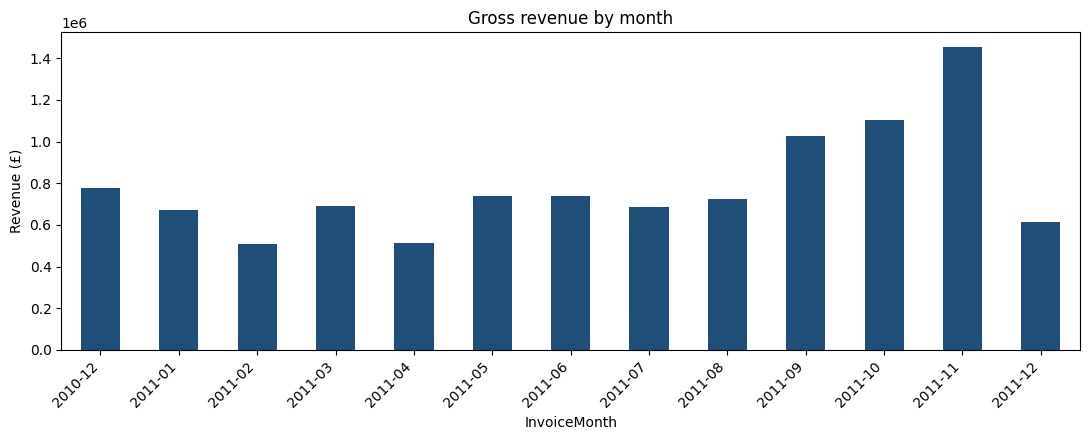

In [5]:
monthly = sales.groupby('InvoiceMonth')['Revenue'].sum()
ax = monthly.plot(kind='bar', color='#1F4E79', figsize=(11, 4.5))
ax.set_title('Gross revenue by month')
ax.set_ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
full_months = monthly.index[monthly.index != '2011-12']
jan_aug = [m for m in full_months if '2011-01' <= m <= '2011-08']
print(f"Jan-Aug 2011 average: £{monthly[jan_aug].mean():,.0f}")
print(f"November 2011:        £{monthly['2011-11']:,.0f}  "
      f"({monthly['2011-11']/monthly[jan_aug].mean():.2f}x the Jan-Aug average)")

Jan-Aug 2011 average: £659,237
November 2011:        £1,452,116  (2.20x the Jan-Aug average)


## 4. Who are the customers? A quick RFM cut

The full RFM segmentation (with business-defined frequency bands) lives in `src/analysis.py::customer_table`. Here's a simplified version for exploration.

In [7]:
ident = sales.dropna(subset=['CustomerID'])
snapshot = sales['InvoiceDate'].max() + pd.Timedelta(days=1)

cust = ident.groupby('CustomerID').agg(
    last_order=('InvoiceDate', 'max'),
    orders=('InvoiceNo', 'nunique'),
    revenue=('Revenue', 'sum'),
)
cust['recency_days'] = (snapshot - cust['last_order']).dt.days
cust = cust.sort_values('revenue', ascending=False)
cust.head(10)

,last_order,orders,revenue,recency_days
CustomerID,,,,
14646.0,2011-12-08 12:12:00,72,279138.02,2
18102.0,2011-12-09 11:50:00,60,259657.30,1
17450.0,2011-12-01 13:29:00,46,194390.79,8
16446.0,2011-12-09 09:15:00,2,168472.50,1
14911.0,2011-12-08 15:54:00,198,136161.83,1
12415.0,2011-11-15 14:22:00,20,124564.53,24
14156.0,2011-11-30 10:54:00,54,116560.08,10
17511.0,2011-12-07 10:12:00,31,91062.38,3
12346.0,2011-01-18 10:01:00,1,77183.60,326


In [8]:
# Revenue concentration: what % of revenue comes from the top X% of customers?
sorted_rev = cust['revenue'].sort_values(ascending=False)
cum_share = sorted_rev.cumsum() / sorted_rev.sum()
for pct in [0.01, 0.05, 0.10, 0.20]:
    k = int(len(cust) * pct)
    print(f"Top {pct:.0%} of customers ({k:,}) = {cum_share.iloc[k-1]:.1%} of identified net revenue")

Top 1% of customers (43) = 32.0% of identified net revenue
Top 5% of customers (216) = 50.4% of identified net revenue
Top 10% of customers (433) = 61.4% of identified net revenue
Top 20% of customers (866) = 74.6% of identified net revenue


## 5. Repeat purchase behaviour

Repeat customer rate: 65.3%
Revenue share from repeat customers: 92.8%


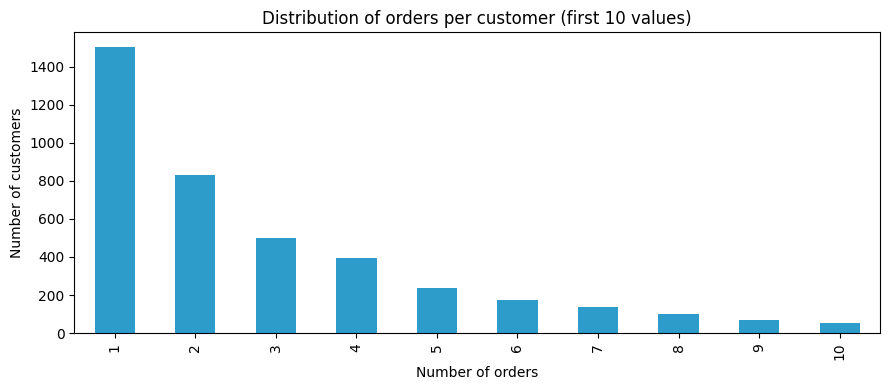

In [9]:
orders_per_cust = cust['orders']
repeat_rate = (orders_per_cust >= 2).mean()
repeat_rev_share = cust.loc[orders_per_cust >= 2, 'revenue'].sum() / cust['revenue'].sum()
print(f"Repeat customer rate: {repeat_rate:.1%}")
print(f"Revenue share from repeat customers: {repeat_rev_share:.1%}")

orders_per_cust.value_counts().sort_index().head(10).plot(
    kind='bar', color='#2E9CCA', figsize=(9, 4))
plt.title('Distribution of orders per customer (first 10 values)')
plt.xlabel('Number of orders')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

## 6. Top products

In [10]:
top_products = (sales.groupby(['StockCode', 'Description'])['Revenue']
                .sum().sort_values(ascending=False).head(10))
top_products

StockCode  Description                       
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    106415.23
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
23084      RABBIT NIGHT LIGHT                     66870.03
22086      PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
84879      ASSORTED COLOUR BIRD ORNAMENT          58927.62
79321      CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

## 7. Returns — headline vs. genuine rate

See `docs/methodology.md` section 3 for how same-day order reversals are identified and why they matter.

In [11]:
return_rate = ret / gross
print(f"Headline return rate: {return_rate:.1%}")

# Quick same-day reversal check (full logic in src/analysis.py::flag_reversals)
s = ident[['CustomerID', 'StockCode', 'Quantity', 'InvoiceDate']].rename(
    columns={'InvoiceDate': 'sale_time'})
r = returns.dropna(subset=['CustomerID']).copy()
r['abs_qty'] = -r['Quantity']
m = r.merge(s, left_on=['CustomerID', 'StockCode', 'abs_qty'],
           right_on=['CustomerID', 'StockCode', 'Quantity'], suffixes=('', '_s'))
m = m[(m['InvoiceDate'] >= m['sale_time']) &
     (m['InvoiceDate'] - m['sale_time'] <= pd.Timedelta(hours=24))]
reversal_value = r.loc[r.index.isin(m.index), 'ReturnValue'].sum()
print(f"Same-day reversal value: £{reversal_value:,.0f} "
      f"({reversal_value/ret:.1%} of all return value)")
print(f"Adjusted (genuine) return rate: {(ret - reversal_value)/(gross - reversal_value):.1%}")

Headline return rate: 4.6%
Same-day reversal value: £15,919 (3.3% of all return value)
Adjusted (genuine) return rate: 4.5%


## Next steps

For the full analysis — RFM with proper frequency bands, cohort retention,
Pareto product analysis, geographic concentration, and the executive
dashboard — see:

- `src/analysis.py` — all computed metrics and tables
- `src/charts.py` — all 13 charts + the dashboard
- `reports/Intermediate_Level_Customer_Revenue_Analysis.pdf` — the full
  narrative report
- `outputs/tables/` — every underlying number as CSV